# 04 — Cross-Coding & Temporal Analysis

Coding label evolution by phase, annual trend lines, statistical association tests, country × coding heatmaps, and a culminating 4-level summary Sankey.

**Requires:** `data/processed/corpus_clean.parquet` and `data/processed/countries_long.parquet` (run NB00 and NB01 first)

In [2]:
# ── CONFIG ────────────────────────────────────────────────────────────────────
PROCESSED_DIR  = "../data/processed/"
OUTPUTS_DIR    = "../outputs/"
TOP_COUNTRIES_N = 10

In [3]:
# ── LOAD ──────────────────────────────────────────────────────────────────────
import sys
sys.path.insert(0, "..")

import warnings
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from IPython.display import display

from scripts.utils import (
    load_processed, crosstab_with_pct,
    save_figure, STYLE,
)

df          = load_processed("corpus_clean")
ctr_long    = load_processed("countries_long")
N           = len(df)
print(f"Corpus: N={N}")

Corpus: N=329


## 1 · Study Approach by Phase

In [4]:
def stacked_phase_bar(df, col, palette, title, filename):
    """Stacked bar of col by phase with count/% toggle."""
    phase_order = ["Phase 1 (2000–12)", "Phase 2 (2012–19)", "Phase 3 (2019–26)"]
    grouped = (
        df.groupby(["phase", col])
        .size()
        .unstack(fill_value=0)
        .reindex(phase_order)
    )
    totals = grouped.sum(axis=1)
    grouped_pct = grouped.div(totals, axis=0).mul(100).round(1)

    fig = go.Figure()
    cats = grouped.columns.tolist()

    traces_count = []
    traces_pct   = []

    for cat in cats:
        color = palette.get(cat, "#9E9E9E")
        counts_vals = grouped[cat].tolist()
        pct_vals    = grouped_pct[cat].tolist()

        traces_count.append(go.Bar(
            name=cat, x=[f"{p}<br>(N={t})" for p, t in zip(grouped.index, totals)],
            y=counts_vals, marker_color=color,
            text=[str(v) if v > 0 else "" for v in counts_vals],
            textposition="inside", textfont=dict(size=10, color="white"),
            visible=True,
        ))
        traces_pct.append(go.Bar(
            name=cat, x=[f"{p}<br>(N={t})" for p, t in zip(grouped.index, totals)],
            y=pct_vals, marker_color=color,
            text=[f"{v:.0f}%" if v > 0 else "" for v in pct_vals],
            textposition="inside", textfont=dict(size=10, color="white"),
            visible=False,
        ))

    for t in traces_count + traces_pct:
        fig.add_trace(t)

    n_cats = len(cats)
    fig.update_layout(
        barmode="stack",
        title=title,
        xaxis_title="Phase",
        yaxis_title="Papers",
        legend_title=col.replace("_", " ").title(),
        height=480,
        updatemenus=[dict(
            type="buttons", direction="right",
            x=0.0, y=1.12, xanchor="left",
            buttons=[
                dict(label="Count",
                     method="update",
                     args=[{"visible": [True]*n_cats + [False]*n_cats},
                           {"yaxis.title.text": "Papers"}]),
                dict(label="Percent",
                     method="update",
                     args=[{"visible": [False]*n_cats + [True]*n_cats},
                           {"yaxis.title.text": "% of phase"}]),
            ],
        )],
    )
    fig.show()
    save_figure(fig, filename)

stacked_phase_bar(
    df.dropna(subset=["study_approach"]),
    "study_approach", STYLE["study_approach"],
    f"Study Approach by Phase (N={N})",
    "04_approach_by_phase",
)

## 2 · Contribution Type by Phase

In [5]:
stacked_phase_bar(
    df.dropna(subset=["contribution_type"]),
    "contribution_type", STYLE["contribution_type"],
    f"Contribution Type by Phase (N={N})",
    "04_contribution_by_phase",
)

## 3 · Annual Trend Lines — Top Study Approaches

In [6]:
top4_approaches = (
    df["study_approach"].value_counts().head(4).index.tolist()
)

annual_sa = (
    df[df["study_approach"].isin(top4_approaches)]
    .groupby(["Year", "study_approach"])
    .size()
    .reset_index(name="N")
)

fig = go.Figure()
for approach in top4_approaches:
    sub = annual_sa[annual_sa["study_approach"] == approach]
    fig.add_trace(go.Scatter(
        x=sub["Year"], y=sub["N"],
        mode="lines+markers",
        name=approach,
        line=dict(color=STYLE["study_approach"].get(approach, "#9E9E9E"), width=2),
        marker=dict(size=6),
    ))

# Phase shading
for p in [
    {"name": "Phase 1", "x0": 1999.5, "x1": 2012.5, "color": "rgba(173,216,230,0.15)"},
    {"name": "Phase 2", "x0": 2012.5, "x1": 2019.5, "color": "rgba(255,200,100,0.15)"},
    {"name": "Phase 3", "x0": 2019.5, "x1": 2026.5, "color": "rgba(144,238,144,0.15)"},
]:
    fig.add_vrect(x0=p["x0"], x1=p["x1"], fillcolor=p["color"], layer="below", line_width=0)

fig.update_layout(
    title=f"Annual Trend — Top 4 Study Approaches (N={N})",
    xaxis=dict(title="Year", dtick=2, tickangle=-45),
    yaxis=dict(title="Papers per year"),
    legend_title="Study Approach",
    height=450,
)
fig.show()
save_figure(fig, "04_approach_trends_line")

## 4 · Statistical Association Tests

In [7]:
def cramers_v(chi2, n, k, r):
    """Cramér's V from chi2, sample size, and table dimensions."""
    return np.sqrt(chi2 / (n * (min(k, r) - 1)))

tests = [
    ("contribution_type", "study_approach"),
    ("phase",             "contribution_type"),
    ("phase",             "study_approach"),
    ("relevance_level",   "contribution_type"),
]

results = []
for row_var, col_var in tests:
    sub = df.dropna(subset=[row_var, col_var])
    ct  = pd.crosstab(sub[row_var], sub[col_var])
    chi2, p, dof, expected = chi2_contingency(ct)
    n_sub = sub.shape[0]
    k, r  = ct.shape
    v = cramers_v(chi2, n_sub, k, r)
    min_expected = expected.min()
    warn = "⚠ low expected cell" if min_expected < 5 else ""
    results.append({
        "Row": row_var, "Col": col_var,
        "N": n_sub, "χ²": round(chi2, 2), "df": dof,
        "p": f"{p:.4f}", "Cramér's V": round(v, 3),
        "Min expected": round(min_expected, 1), "Note": warn,
    })

chi2_df = pd.DataFrame(results)
display(chi2_df)
chi2_df.to_parquet(PROCESSED_DIR + "chi2_results.parquet", index=False)
print("✓ chi2_results.parquet exported")

,Row,Col,N,χ²,df,p,Cramér's V,Min expected,Note
0,contribution_type,study_approach,329,734.98,28,0.0000,0.747,0.8,⚠ low expected cell
1,phase,contribution_type,329,35.60,8,0.0000,0.233,3.9,⚠ low expected cell
2,phase,study_approach,329,50.14,14,0.0000,0.276,2.6,⚠ low expected cell
3,relevance_level,contribution_type,329,62.56,8,0.0000,0.308,2.1,⚠ low expected cell


✓ chi2_results.parquet exported


## 5 · Country × Contribution Type Heatmap

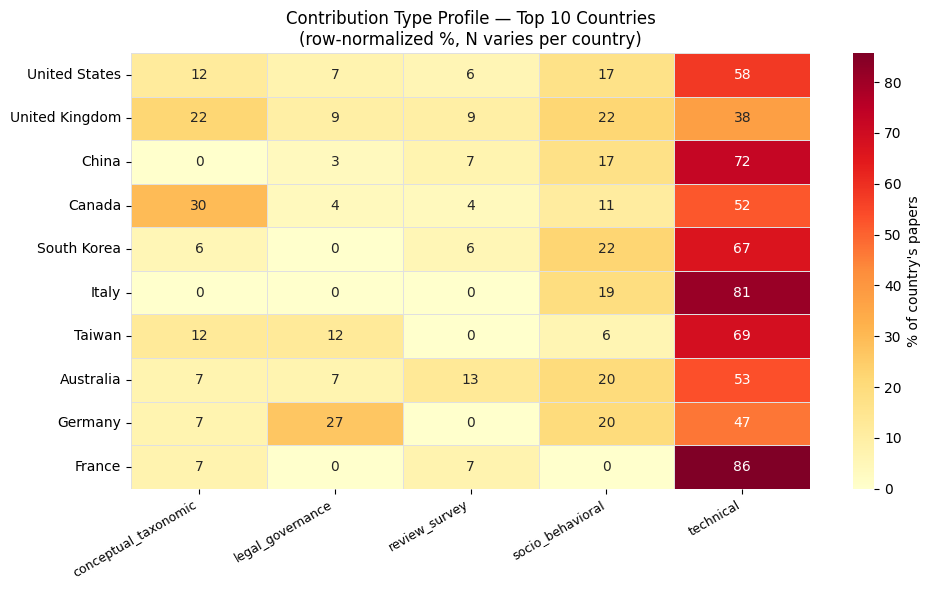

✓ 04_country_contribution_heatmap.svg + .png saved


In [ ]:
# Join countries_long → corpus
ctr_df = (
    ctr_long
    .drop_duplicates(subset=["Record_ID", "value"])
    .merge(df[["Record_ID", "contribution_type", "study_approach"]], on="Record_ID", how="left")
    .rename(columns={"value": "country"})
    .dropna(subset=["contribution_type", "study_approach"])
)

# Top N countries by paper count
top_countries = (
    ctr_df.drop_duplicates(subset=["Record_ID", "country"])
    .groupby("country")["Record_ID"]
    .nunique()
    .nlargest(TOP_COUNTRIES_N)
    .index.tolist()
)

ctr_top = ctr_df[ctr_df["country"].isin(top_countries)]

# Contribution type heatmap
#ct_heat = pd.crosstab(ctr_top["country"], ctr_top["contribution_type"], normalize="index").mul(100).round(1)
ct_heat = pd.crosstab(ctr_top["country"], ctr_top["contribution_type"])
ct_heat = ct_heat.reindex(top_countries)

fig_ct, ax_ct = plt.subplots(figsize=(10, 6))
sns.heatmap(
    ct_heat, ax=ax_ct,
    annot=True, fmt=".0f", cmap="YlOrRd",
    linewidths=0.5, linecolor="#E0E0E0",
    cbar_kws={"label": "% of country's papers"},
)
ax_ct.set_title(f"Contribution Type Profile — Top {TOP_COUNTRIES_N} Countries\n(row-normalized %, N varies per country)",
                fontsize=12)
ax_ct.set_xlabel(""); ax_ct.set_ylabel("")
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR + "04_country_contribution_heatmap.svg", bbox_inches="tight")
plt.savefig(OUTPUTS_DIR + "04_country_contribution_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ 04_country_contribution_heatmap.svg + .png saved")

## 6 · Country × Study Approach Heatmap

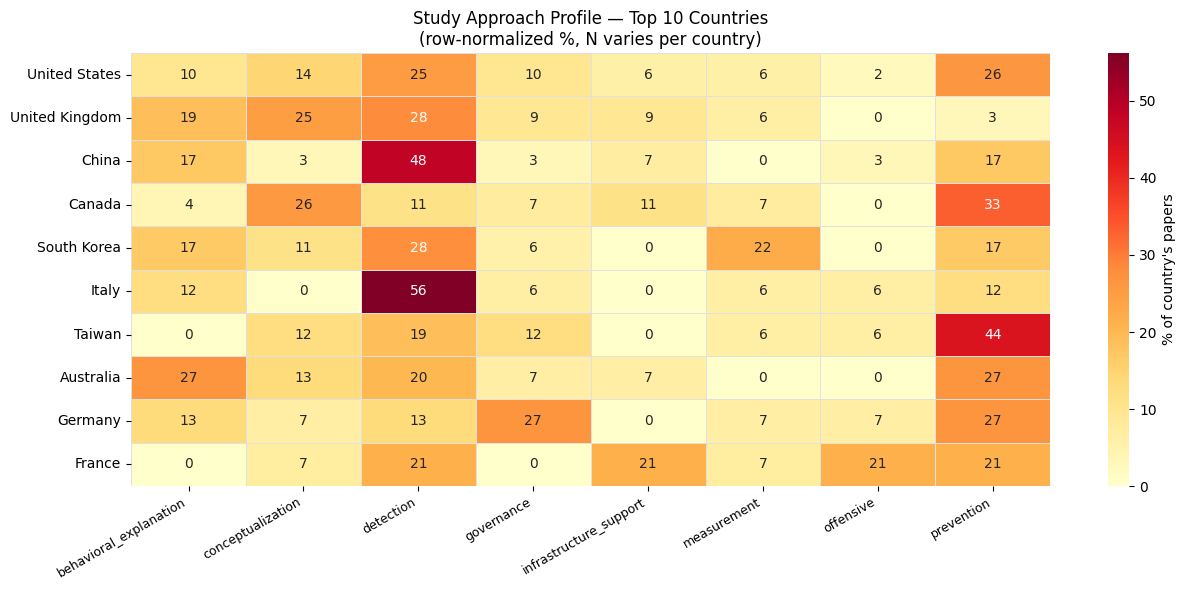

✓ 04_country_approach_heatmap.svg + .png saved


In [9]:
sa_heat = pd.crosstab(ctr_top["country"], ctr_top["study_approach"], normalize="index").mul(100).round(1)
sa_heat = sa_heat.reindex(top_countries)

fig_sa, ax_sa = plt.subplots(figsize=(13, 6))
sns.heatmap(
    sa_heat, ax=ax_sa,
    annot=True, fmt=".0f", cmap="YlOrRd",
    linewidths=0.5, linecolor="#E0E0E0",
    cbar_kws={"label": "% of country's papers"},
)
ax_sa.set_title(f"Study Approach Profile — Top {TOP_COUNTRIES_N} Countries\n(row-normalized %, N varies per country)",
                fontsize=12)
ax_sa.set_xlabel(""); ax_sa.set_ylabel("")
plt.xticks(rotation=30, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUTS_DIR + "04_country_approach_heatmap.svg", bbox_inches="tight")
plt.savefig(OUTPUTS_DIR + "04_country_approach_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ 04_country_approach_heatmap.svg + .png saved")

## 7 · Summary Sankey: Phase → Relevance Level → Contribution Type → Study Approach

In [10]:
df_valid = df[
    df["phase"].apply(lambda p: str(p).startswith("Phase"))
    & df["contribution_type"].notna()
    & df["study_approach"].notna()
].copy()

phases  = sorted(df_valid["phase"].unique(), key=lambda p: int(p.split()[1]))
ct_vals = df_valid["contribution_type"].value_counts().index.tolist()
sa_vals = df_valid["study_approach"].value_counts().index.tolist()

all_nodes = phases + ct_vals + sa_vals
node_idx  = {n: i for i, n in enumerate(all_nodes)}

def node_count(field, val):
    return int(df_valid[field].value_counts().get(val, 0))

node_labels = (
    [f"{p}<br>(N={node_count('phase', p)})" for p in phases]
    + [f"{v}<br>(N={node_count('contribution_type', v)})" for v in ct_vals]
    + [f"{v}<br>(N={node_count('study_approach', v)})" for v in sa_vals]
)
node_colors = (
    [STYLE["phase"].get(p, "#90CAF9") for p in phases]
    + [STYLE["contribution_type"].get(v, "#BDBDBD") for v in ct_vals]
    + [STYLE["study_approach"].get(v, "#BDBDBD") for v in sa_vals]
)

def _spread(n, lo=0.05, hi=0.95):
    return [0.5] if n <= 1 else [round(lo + i * (hi - lo) / (n - 1), 4) for i in range(n)]

n_ph, n_ct, n_sa = len(phases), len(ct_vals), len(sa_vals)
node_x = [0.001] * n_ph + [0.45] * n_ct + [0.99] * n_sa
node_y = _spread(n_ph)  + _spread(n_ct) + _spread(n_sa)

link_src, link_tgt, link_val, link_lbl = [], [], [], []

def add_links(df_grp, from_col, to_col):
    for (f, t), grp in df_grp.groupby([from_col, to_col], sort=False):
        if f in node_idx and t in node_idx:
            cnt = len(grp)
            link_src.append(node_idx[f]); link_tgt.append(node_idx[t])
            link_val.append(cnt);         link_lbl.append(str(cnt))

add_links(df_valid, "phase",             "contribution_type")
add_links(df_valid, "contribution_type", "study_approach")

fig = go.Figure(go.Sankey(
    arrangement="snap",
    node=dict(
        label=node_labels, color=node_colors,
        x=node_x, y=node_y,
        pad=12, thickness=16,
        line=dict(color="#555", width=0.4),
    ),
    link=dict(
        source=link_src, target=link_tgt,
        value=link_val, label=link_lbl,
        hovertemplate="%{source.label} → %{target.label}<br>N=%{value}<extra></extra>",
    ),
))
fig.update_layout(
    title_text=f"Summary Sankey: Phase → Contribution → Approach (N={len(df_valid)})",
    font_size=11,
    height=680,
    margin=dict(r=200),
)
fig.show()
save_figure(fig, "04_summary_sankey")